# World Happiness — Neural Network Predictions 2026–2030

Uses two complementary neural architectures trained on `happiness_clean.csv`:

| Model | Architecture | Input |
|---|---|---|
| **LSTM** | Sequence model, learns temporal patterns per country | 3-year rolling window of scores + rank |
| **Transformer** | Attention over full history per country | All available years as a sequence |

Both models predict year-by-year scores from 2026 to 2030.  
Run `main_analysis.ipynb` first to generate `happiness_clean.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, math
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")
DEVICE = torch.device("cpu")
print("PyTorch:", torch.__version__, "| Device:", DEVICE)

df = pd.read_csv("happiness_clean.csv")
print("Data shape:", df.shape)
df.head(3)

PyTorch: 2.11.0+cpu | Device: cpu
Data shape: (2116, 22)


,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,...,dystopia_plus_residual,tier,has_breakdown,score_change_yoy,region,years_in_dataset,coverage_pct,score_std,z_score,is_outlier
0,2011,131,Afghanistan,4.258,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Bottom,False,NaN,South Asia,14,100.0,0.95,-1.032,False
1,2012,143,Afghanistan,4.040,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Bottom,False,-0.218,South Asia,14,100.0,0.95,-1.251,False
2,2014,153,Afghanistan,3.575,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Bottom,False,-0.465,South Asia,14,100.0,0.95,-1.573,False


## 1  Prepare sequences

In [2]:
# Keep only countries with at least 6 years of data (needed for seq models)
year_counts = df.groupby("country")["year"].count()
valid_countries = year_counts[year_counts >= 6].index.tolist()
df_model = df[df["country"].isin(valid_countries)].copy()
df_model = df_model.sort_values(["country", "year"]).reset_index(drop=True)

print(f"Countries with >= 6 years: {len(valid_countries)}")
print(f"Years in dataset: {sorted(df_model['year'].unique())}")

# Encode year as 0-indexed position per country for positional embedding
df_model["year_idx"] = df_model.groupby("country").cumcount()

# Fit scaler only on pre-2023 training data to prevent val-set leakage
train_rows = df_model[df_model["year"] < 2023]
scaler = MinMaxScaler()
scaler.fit(train_rows[["happiness_score"]])
df_model["score_scaled"] = scaler.transform(df_model[["happiness_score"]])
df_model["rank_scaled"]  = df_model["rank_in_year"] / df_model.groupby("year")["rank_in_year"].transform("max")

print(df_model[["country","year","happiness_score","score_scaled"]].head(8))

Countries with >= 6 years: 156
Years in dataset: [np.int64(2011), np.int64(2012), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
       country  year  happiness_score  score_scaled
0  Afghanistan  2011           4.2580      0.400033
1  Afghanistan  2012           4.0400      0.363682
2  Afghanistan  2014           3.5750      0.286143
3  Afghanistan  2015           3.3600      0.250292
4  Afghanistan  2016           3.7940      0.322661
5  Afghanistan  2017           3.6320      0.295648
6  Afghanistan  2018           3.2030      0.224112
7  Afghanistan  2019           2.5669      0.118042


## 2  Build sequence windows

In [3]:
SEQ_LEN = 4   # use 4 years to predict the next year

def build_sequences(group):
    scores = group["score_scaled"].values
    ranks  = group["rank_scaled"].values
    X, y, meta = [], [], []
    for i in range(len(scores) - SEQ_LEN):
        feat_seq = np.stack([scores[i:i+SEQ_LEN], ranks[i:i+SEQ_LEN]], axis=1)  # (SEQ_LEN, 2)
        X.append(feat_seq)
        y.append(scores[i + SEQ_LEN])
        meta.append((group["country"].iloc[0], group["year"].iloc[i + SEQ_LEN]))
    return X, y, meta

all_X, all_y, all_meta = [], [], []
for country, grp in df_model.groupby("country"):
    X, y, meta = build_sequences(grp.reset_index(drop=True))
    all_X.extend(X)
    all_y.extend(y)
    all_meta.extend(meta)

X_arr = np.array(all_X, dtype=np.float32)   # (N, SEQ_LEN, 2)
y_arr = np.array(all_y, dtype=np.float32)   # (N,)

# Train/val split by time: last 2 years as validation
meta_df = pd.DataFrame(all_meta, columns=["country","year"])
val_mask = meta_df["year"] >= 2023

X_train = torch.tensor(X_arr[~val_mask.values])
y_train = torch.tensor(y_arr[~val_mask.values]).unsqueeze(1)
X_val   = torch.tensor(X_arr[val_mask.values])
y_val   = torch.tensor(y_arr[val_mask.values]).unsqueeze(1)

print(f"Train samples: {len(X_train)} | Val samples: {len(X_val)}")
print(f"X shape: {X_train.shape}  (samples, seq_len, features)")

Train samples: 1021 | Val samples: 432
X shape: torch.Size([1021, 4, 2])  (samples, seq_len, features)


## 3  LSTM model

In [4]:
class LSTMPredictor(nn.Module):
    def __init__(self, input_size=2, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])   # use last timestep


def train_model(model, X_tr, y_tr, X_v, y_v, epochs=150, lr=1e-3, batch=64):
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10, factor=0.5)
    loss_fn = nn.MSELoss()
    loader = DataLoader(list(zip(X_tr, y_tr)), batch_size=batch, shuffle=True)

    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for xb, yb in loader:
            opt.zero_grad()
            pred = model(xb.to(DEVICE))
            loss = loss_fn(pred, yb.to(DEVICE))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            batch_losses.append(loss.item())
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_v.to(DEVICE)), y_v.to(DEVICE)).item()
        tl = np.mean(batch_losses)
        train_losses.append(tl)
        val_losses.append(val_loss)
        sch.step(val_loss)
    return train_losses, val_losses


lstm_model = LSTMPredictor().to(DEVICE)
print(f"LSTM parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")
tr_loss, val_loss = train_model(lstm_model, X_train, y_train, X_val, y_val, epochs=200)
print(f"Final val loss: {val_loss[-1]:.6f}")

LSTM parameters: 52,801
Final val loss: 0.003146


## 4  Transformer model

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=20):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TransformerPredictor(nn.Module):
    def __init__(self, input_size=2, d_model=32, nhead=4, layers=2, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(input_size, d_model)
        self.pos  = PositionalEncoding(d_model)
        enc_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=64,
                                               dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        x = self.proj(x)
        x = self.pos(x)
        x = self.encoder(x)
        return self.head(x[:, -1, :])


tfm_model = TransformerPredictor().to(DEVICE)
print(f"Transformer parameters: {sum(p.numel() for p in tfm_model.parameters()):,}")
tr_loss_t, val_loss_t = train_model(tfm_model, X_train, y_train, X_val, y_val, epochs=200)
print(f"Final val loss: {val_loss_t[-1]:.6f}")

Transformer parameters: 17,729
Final val loss: 0.000968


## 5  Training curves

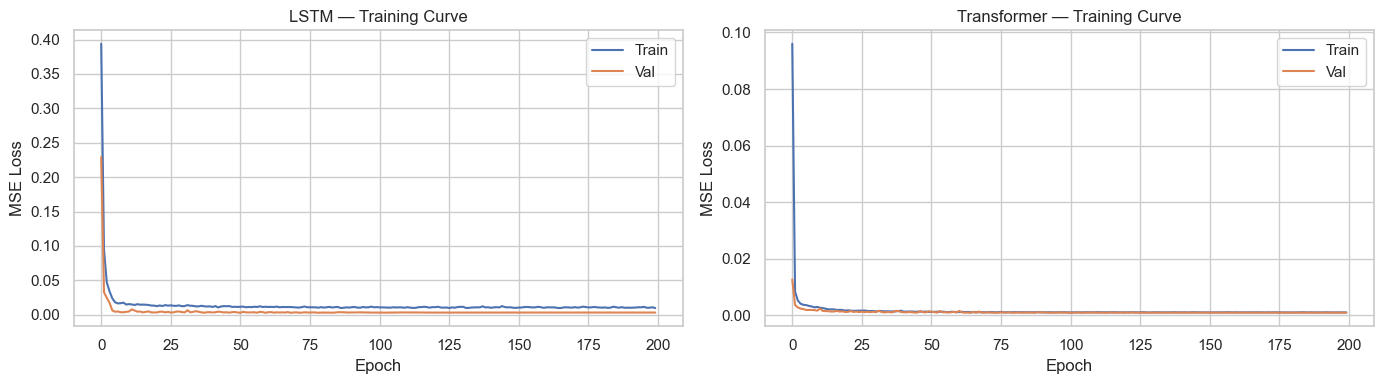

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, tl, vl, name in zip(axes,
                             [tr_loss, tr_loss_t],
                             [val_loss, val_loss_t],
                             ["LSTM", "Transformer"]):
    ax.plot(tl, label="Train")
    ax.plot(vl, label="Val")
    ax.set_title(f"{name} — Training Curve")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()
plt.tight_layout()
plt.savefig("plot_nn_training_curves.png", dpi=150)
plt.show()

## 6  Validation accuracy

In [7]:
def evaluate(model, X, y_scaled, scaler):
    model.eval()
    with torch.no_grad():
        preds_scaled = model(X.to(DEVICE)).cpu().numpy().flatten()
    preds = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    actual = scaler.inverse_transform(y_scaled.numpy().reshape(-1, 1)).flatten()
    mae = mean_absolute_error(actual, preds)
    r2  = r2_score(actual, preds)
    return preds, actual, mae, r2


preds_lstm, actual, mae_lstm, r2_lstm = evaluate(lstm_model, X_val, y_val, scaler)
preds_tfm,  _,      mae_tfm,  r2_tfm  = evaluate(tfm_model, X_val, y_val, scaler)

print(f"{'Model':<20} {'MAE':>8} {'R2':>8}")
print("-" * 38)
print(f"{'LSTM':<20} {mae_lstm:>8.4f} {r2_lstm:>8.4f}")
print(f"{'Transformer':<20} {mae_tfm:>8.4f} {r2_tfm:>8.4f}")

best_model   = lstm_model   if mae_lstm <= mae_tfm else tfm_model
best_name    = "LSTM"       if mae_lstm <= mae_tfm else "Transformer"
best_preds   = preds_lstm   if mae_lstm <= mae_tfm else preds_tfm
print(f"\nBest model: {best_name}")

Model                     MAE       R2
--------------------------------------
LSTM                   0.2569   0.9142
Transformer            0.1396   0.9736

Best model: Transformer


## 7  Predicted vs actual on validation set

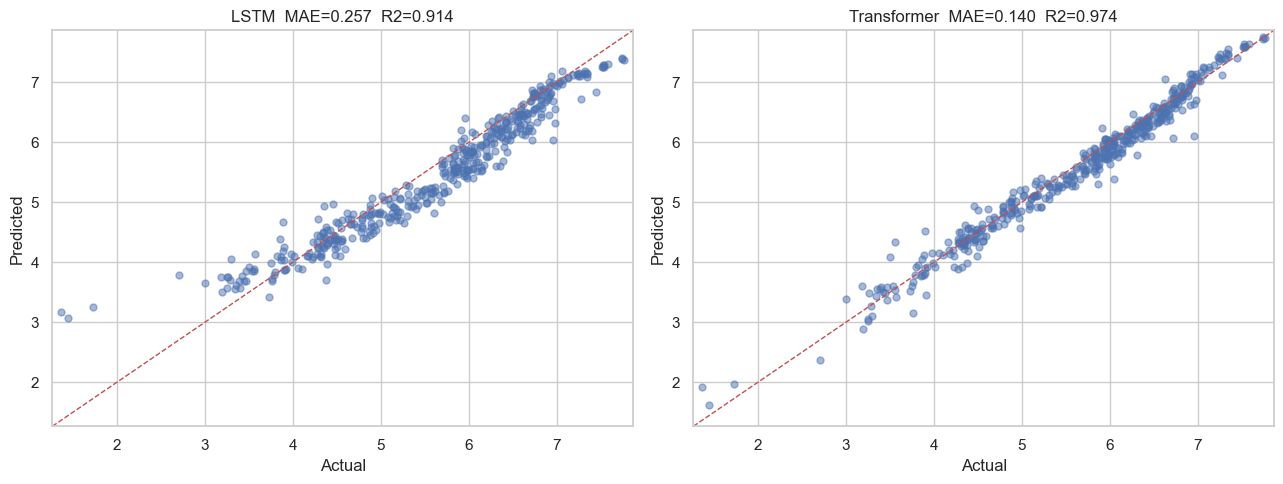

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, name, mae, r2 in zip(axes,
                                     [preds_lstm, preds_tfm],
                                     ["LSTM", "Transformer"],
                                     [mae_lstm, mae_tfm],
                                     [r2_lstm, r2_tfm]):
    ax.scatter(actual, preds, alpha=0.5, s=25)
    lo, hi = min(actual.min(), preds.min()) - 0.1, max(actual.max(), preds.max()) + 0.1
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
    ax.set_title(f"{name}  MAE={mae:.3f}  R2={r2:.3f}")
plt.tight_layout()
plt.savefig("plot_nn_pred_vs_actual.png", dpi=150)
plt.show()

## 8  Multi-year forecast 2026–2030

In [9]:
FORECAST_YEARS = [2026, 2027, 2028, 2029, 2030]

def forecast_country(country, model, df_src, scaler, seq_len=SEQ_LEN, n_years=5):
    grp = df_src[df_src["country"] == country].sort_values("year")
    scores_scaled = grp["score_scaled"].values.tolist()
    ranks_scaled  = grp["rank_scaled"].values.tolist()

    predictions = []
    for _ in range(n_years):
        window_s = scores_scaled[-seq_len:]
        window_r = ranks_scaled[-seq_len:]
        seq = torch.tensor([[s, r] for s, r in zip(window_s, window_r)],
                            dtype=torch.float32).unsqueeze(0)
        model.eval()
        with torch.no_grad():
            pred_scaled = model(seq.to(DEVICE)).item()
        pred_score = scaler.inverse_transform([[pred_scaled]])[0][0]
        predictions.append(pred_score)
        # feed prediction back as next step
        scores_scaled.append(pred_scaled)
        ranks_scaled.append(ranks_scaled[-1])   # rank approximated as stable

    return predictions


# Run forecast for every country that has 2025 data
countries_2025 = df_model[df_model["year"] == 2025]["country"].unique()

rows = []
for country in countries_2025:
    preds_lstm_c = forecast_country(country, lstm_model, df_model, scaler)
    preds_tfm_c  = forecast_country(country, tfm_model,  df_model, scaler)
    for i, yr in enumerate(FORECAST_YEARS):
        rows.append({
            "country": country,
            "year": yr,
            "lstm_score": round(preds_lstm_c[i], 4),
            "transformer_score": round(preds_tfm_c[i], 4),
            "ensemble_score": round((preds_lstm_c[i] + preds_tfm_c[i]) / 2, 4),
        })

forecast_df = pd.DataFrame(rows)
print(f"Forecast rows: {len(forecast_df)}")
forecast_df.head(10)

Forecast rows: 725


,country,year,lstm_score,transformer_score,ensemble_score
0,Afghanistan,2026,3.0175,1.8456,2.4316
1,Afghanistan,2027,3.1230,2.2910,2.7070
2,Afghanistan,2028,3.2860,2.6744,2.9802
3,Afghanistan,2029,3.4442,2.9172,3.1807
4,Afghanistan,2030,3.5593,3.1253,3.3423
5,Albania,2026,5.1886,5.5878,5.3882
6,Albania,2027,5.1909,5.4710,5.3309
7,Albania,2028,5.1696,5.3469,5.2582
8,Albania,2029,5.1406,5.2693,5.2049
9,Albania,2030,5.1073,5.2396,5.1735


## 9  Forecast table — top & bottom countries

In [10]:
for yr in FORECAST_YEARS:
    yr_df = forecast_df[forecast_df["year"] == yr].sort_values("ensemble_score", ascending=False)
    yr_df["rank"] = range(1, len(yr_df) + 1)
    print(f"\n=== {yr} — Top 10 (Ensemble) ===")
    print(yr_df[["rank","country","lstm_score","transformer_score","ensemble_score"]].head(10).to_string(index=False))
    print(f"\n=== {yr} — Bottom 5 ===")
    print(yr_df[["rank","country","ensemble_score"]].tail(5).to_string(index=False))


=== 2026 — Top 10 (Ensemble) ===
 rank     country  lstm_score  transformer_score  ensemble_score
    1     Finland      7.3717             7.7511          7.5614
    2     Denmark      7.2674             7.6059          7.4366
    3     Iceland      7.2537             7.6189          7.4363
    4      Sweden      7.1419             7.3762          7.2591
    5  Costa Rica      7.0129             7.4753          7.2441
    6      Norway      7.0926             7.3613          7.2270
    7 Netherlands      7.1129             7.3260          7.2195
    8      Israel      7.0922             7.2943          7.1933
    9  Luxembourg      6.9989             7.1743          7.0866
   10 Switzerland      6.9398             7.1643          7.0521

=== 2026 — Bottom 5 ===
 rank      country  ensemble_score
  141     Botswana          3.6435
  142     Zimbabwe          3.5432
  143       Malawi          3.5194
  144 Sierra Leone          3.5063
  145  Afghanistan          2.4316

=== 2027 — Top 

## 10  Trend plot — selected countries 2011–2030

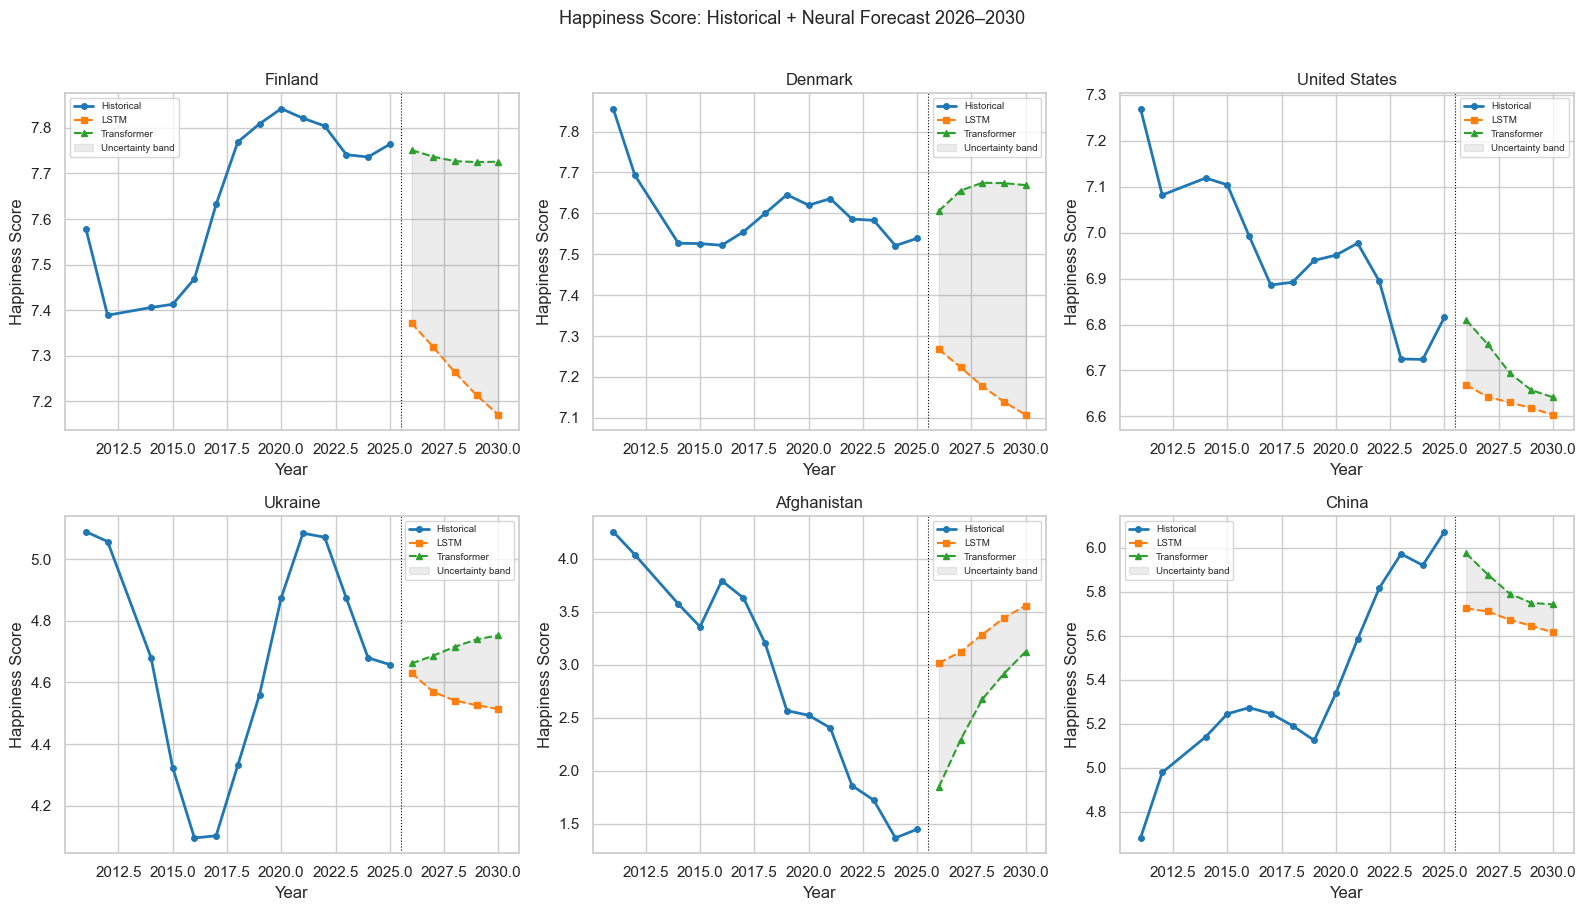

In [11]:
HIGHLIGHT = ["Finland", "Denmark", "United States", "Ukraine", "Afghanistan", "China"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
palette = sns.color_palette("tab10", 3)

for ax, country in zip(axes.flatten(), HIGHLIGHT):
    hist = df[df["country"] == country].sort_values("year")
    ax.plot(hist["year"], hist["happiness_score"], "o-", color=palette[0],
            lw=2, ms=4, label="Historical")

    fc = forecast_df[forecast_df["country"] == country]
    if len(fc):
        ax.plot(fc["year"], fc["lstm_score"],        "s--", color=palette[1], lw=1.5, ms=4, label="LSTM")
        ax.plot(fc["year"], fc["transformer_score"], "^--", color=palette[2], lw=1.5, ms=4, label="Transformer")
        ax.fill_between(fc["year"],
                        fc[["lstm_score","transformer_score"]].min(axis=1),
                        fc[["lstm_score","transformer_score"]].max(axis=1),
                        alpha=0.15, color="grey", label="Uncertainty band")
        ax.axvline(2025.5, color="black", lw=0.8, ls=":")

    ax.set_title(country)
    ax.set_xlabel("Year")
    ax.set_ylabel("Happiness Score")
    ax.legend(fontsize=7)

plt.suptitle("Happiness Score: Historical + Neural Forecast 2026–2030", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("plot_nn_forecast_trends.png", dpi=150)
plt.show()

## 11  Save forecasts

In [12]:
forecast_df.to_csv("happiness_neural_forecast_2026_2030.csv", index=False)
print("Saved: happiness_neural_forecast_2026_2030.csv")
print(forecast_df.groupby("year")["ensemble_score"].agg(["mean","min","max"]).round(3))

Saved: happiness_neural_forecast_2026_2030.csv
       mean    min    max
year                     
2026  5.552  2.432  7.561
2027  5.535  2.707  7.528
2028  5.516  2.980  7.495
2029  5.503  3.181  7.469
2030  5.496  3.342  7.448
